In [87]:
import pandas as pd
import numpy as np

# EDA

In [88]:
df = pd.read_csv('car_price.csv')

In [89]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [90]:
df.shape

(72435, 10)

In [91]:
df.dtypes

model               str
year            float64
price           float64
transmission        str
mileage         float64
fuelType            str
tax             float64
mpg             float64
engineSize      float64
Make                str
dtype: object

In [92]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

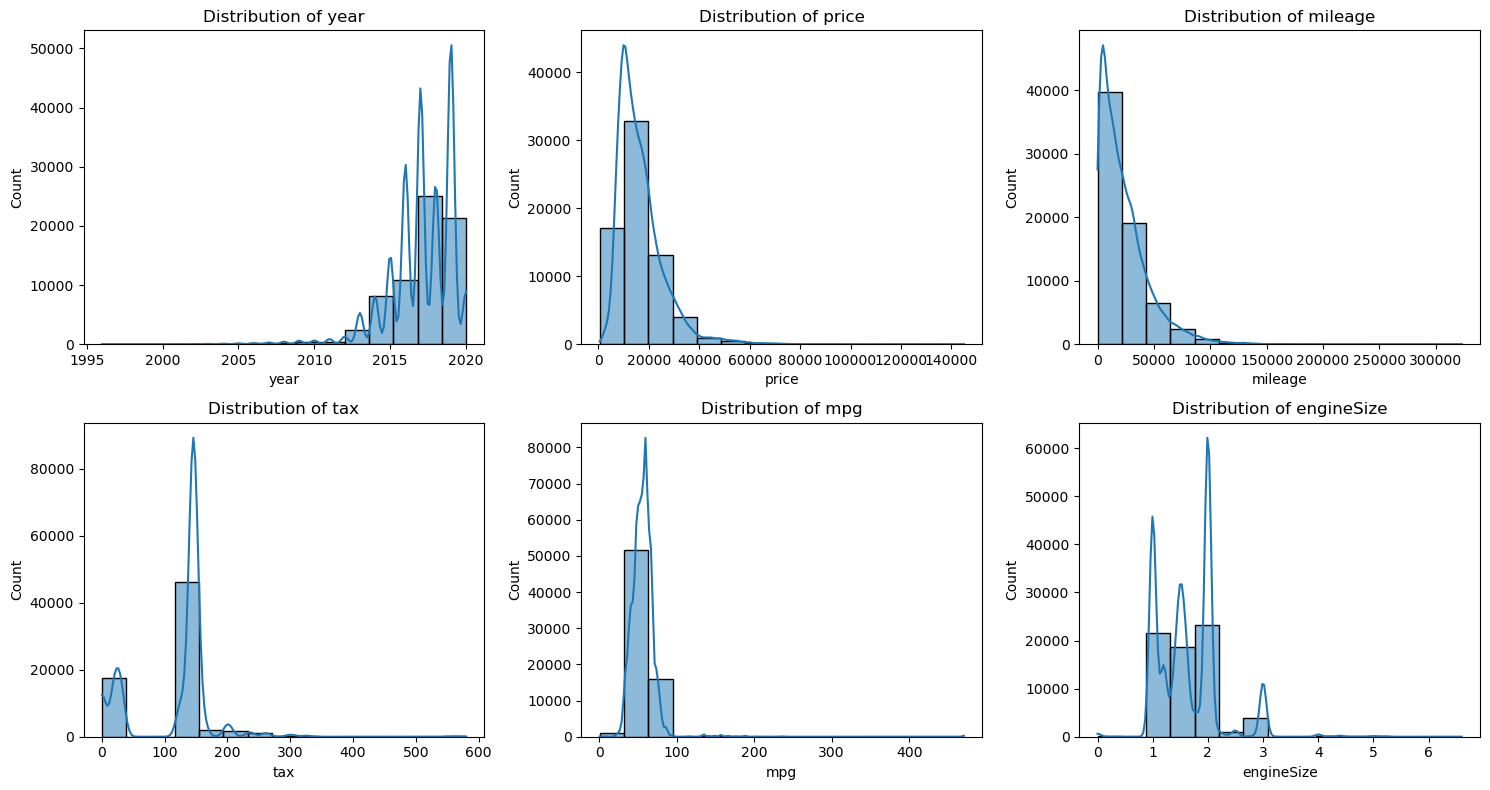

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = numeric_cols.columns
n = len(cols)

cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 4 * rows))

axes = axes.flatten() 

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, bins=15, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<Axes: >

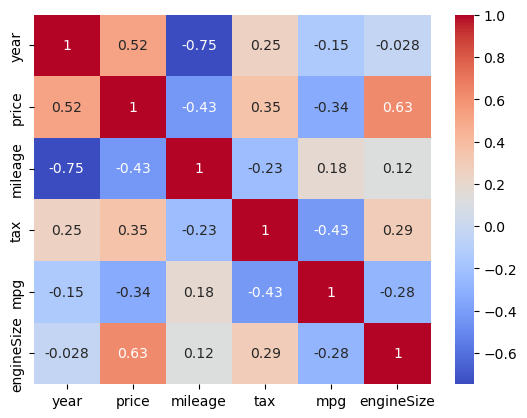

In [94]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

# Preprocessing

In [95]:
df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

In [96]:
# Feature engineering

df['Car Age'] = 2026 - df['year']

def engine_group(x):
    if x < 1.6:
        return 'Small'
    elif x < 2.5:
        return 'Medium'
    else:
        return 'Large'
    

df['Engine Category'] = df['engineSize'].apply(engine_group)
df = df.drop(columns=['engineSize', 'year'])


In [97]:
df_reg = df.dropna(subset=['price'])
df_reg = df_reg.drop(columns=['Make'])
X_reg = df_reg.drop('price', axis=1)
y_reg = df_reg['price']


In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            68814 non-null  str    
 1   price            68814 non-null  float64
 2   transmission     68812 non-null  str    
 3   mileage          68813 non-null  float64
 4   fuelType         68813 non-null  str    
 5   tax              68814 non-null  float64
 6   mpg              68814 non-null  float64
 7   Make             68814 non-null  str    
 8   Car Age          68813 non-null  float64
 9   Engine Category  72435 non-null  str    
dtypes: float64(5), str(5)
memory usage: 5.5 MB


In [99]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler())

engine_categories = [['Small', 'Medium', 'Large']]
engine_pipline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder(categories=engine_categories)
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        ('log', log_pipeline, ['mileage']),
        ('num', numeric_transformer, ['tax','mpg','Car Age']),
        ('cat', categorical_transformer, ['model','transmission','fuelType']),
        ('engine', engine_pipline, ['Engine Category'])
    ]
)


# Regression Model

In [100]:
from sklearn.linear_model import LinearRegression

model = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('regressor', LinearRegression())
])

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2,random_state=42 )

In [102]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [103]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_reg, y_reg, cv=kf)

print(f"R2 Scores: {scores}")
print(f"Average R2: {scores.mean():.4f}")

R2 Scores: [0.83165002 0.8338897  0.84019563 0.82964255 0.83864244]
Average R2: 0.8348


In [104]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2477.309140907676
RMSE: 3784.906208257339
R2 Score: 0.8316500158040074
